In [2]:
#Import and install necessary packages
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
#Load data from file directory
mortality_socio_22 = pd.read_csv("/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 8/mortality_socio_22.csv")

In [4]:
print(mortality_socio_22.columns)

Index(['Unnamed: 0', 'entity', 'code', 'year', 'per_1000', 'income_level',
       'regions', 'gdp_per_capita', 'health_exp_pct_gdp',
       'dtp3_immunization_pct', 'basic_sanitation_pct', 'female_literacy_pct',
       'all_present'],
      dtype='object')


In [6]:
mortality_socio_22_nna = mortality_socio_22['female_literacy_pct'].dropna()
print(mortality_socio_22_nna.shape)

(42,)


In [7]:
# Keep only countries with REAL (non-missing) literacy data
df_literacy = mortality_socio_22.dropna(subset=['female_literacy_pct']).copy()
print(f"Countries with real female literacy data: {df_literacy.shape[0]}")

# Also exclude CAR here, consistent with your primary robustness model
df_literacy = df_literacy[df_literacy['entity'] != 'Central African Republic']
print(f"After excluding CAR: {df_literacy.shape[0]}")

Countries with real female literacy data: 42
After excluding CAR: 42


In [8]:
predictors_with_literacy = [
    'gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct',
    'basic_sanitation_pct', 'female_literacy_pct'
]
target = 'per_1000'

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_literacy[predictors_with_literacy]),
    columns=predictors_with_literacy,
    index=df_literacy.index
)
X_scaled = sm.add_constant(X_scaled)
y = df_literacy[target]

model_literacy = sm.OLS(y, X_scaled).fit()
print(model_literacy.summary())

                            OLS Regression Results                            
Dep. Variable:               per_1000   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     42.03
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           4.77e-14
Time:                        04:00:42   Log-Likelihood:                -155.76
No. Observations:                  42   AIC:                             323.5
Df Residuals:                      36   BIC:                             333.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    29.45

In [9]:
# Compare directly to the 4-predictor model on this SAME subset
# (important: compare apples to apples — same countries, with vs without literacy)
predictors_base = ['gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct', 'basic_sanitation_pct']

scaler2 = StandardScaler()
X_base_scaled = pd.DataFrame(
    scaler2.fit_transform(df_literacy[predictors_base]),
    columns=predictors_base,
    index=df_literacy.index
)
X_base_scaled = sm.add_constant(X_base_scaled)

model_base_subset = sm.OLS(y, X_base_scaled).fit()

print("\n=== Comparison on the SAME subset of countries ===")
print(f"R² without literacy (4 predictors): {model_base_subset.rsquared:.4f}")
print(f"R² with literacy (5 predictors):    {model_literacy.rsquared:.4f}")
print(f"Adj R² without literacy: {model_base_subset.rsquared_adj:.4f}")
print(f"Adj R² with literacy:    {model_literacy.rsquared_adj:.4f}")
print(f"\nFemale literacy p-value: {model_literacy.pvalues['female_literacy_pct']:.4f}")


=== Comparison on the SAME subset of countries ===
R² without literacy (4 predictors): 0.8149
R² with literacy (5 predictors):    0.8537
Adj R² without literacy: 0.7949
Adj R² with literacy:    0.8334

Female literacy p-value: 0.0038


In [10]:
#Validate and check for missing value
print(mortality_socio_22.shape)
print(mortality_socio_22.isna().sum())

#Generate another data excluded the female literacy rate
mortality_socio_22_non_f = mortality_socio_22[['entity', 'code', 'year', 'per_1000', 'income_level', 'regions',
                                               'gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct','basic_sanitation_pct']]
mortality_socio_22_non_f.head()

# Dealing with other column with very little missing values by median imputation
cols_to_impute = ['gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct', 'basic_sanitation_pct']

for col in cols_to_impute:
    mortality_socio_22_non_f[col] = mortality_socio_22_non_f.groupby('income_level')[col].transform(lambda x: x.fillna(x.median()))

# Check nothing's left missing
print(mortality_socio_22_non_f[cols_to_impute].isna().sum())

(168, 13)
Unnamed: 0                 0
entity                     0
code                       0
year                       0
per_1000                   0
income_level               0
regions                    0
gdp_per_capita             4
health_exp_pct_gdp         3
dtp3_immunization_pct      2
basic_sanitation_pct       8
female_literacy_pct      126
all_present                0
dtype: int64
gdp_per_capita           0
health_exp_pct_gdp       0
dtp3_immunization_pct    0
basic_sanitation_pct     0
dtype: int64


/tmp/ipykernel_1198/510179675.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_socio_22_non_f[col] = mortality_socio_22_non_f.groupby('income_level')[col].transform(lambda x: x.fillna(x.median()))
/tmp/ipykernel_1198/510179675.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_socio_22_non_f[col] = mortality_socio_22_non_f.groupby('income_level')[col].transform(lambda x: x.fillna(x.median()))
/tmp/ipykernel_1198/510179675.py:14: SettingWithCopyWarning: 
A value is trying to be set 

In [11]:
#Setting up data for modelling
#import statsmodels.api as sm
predictors = ['gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct', 'basic_sanitation_pct']
target = 'per_1000'

#Fit on CAR-excluded data (our validated primary model for this analysis)
df_no_car = mortality_socio_22_non_f[mortality_socio_22_non_f['entity'] != 'Central African Republic'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_no_car[predictors]),
    columns=predictors,
    index=df_no_car.index
)
X_scaled = sm.add_constant(X_scaled)
y = df_no_car[target]

model = sm.OLS(y, X_scaled).fit()

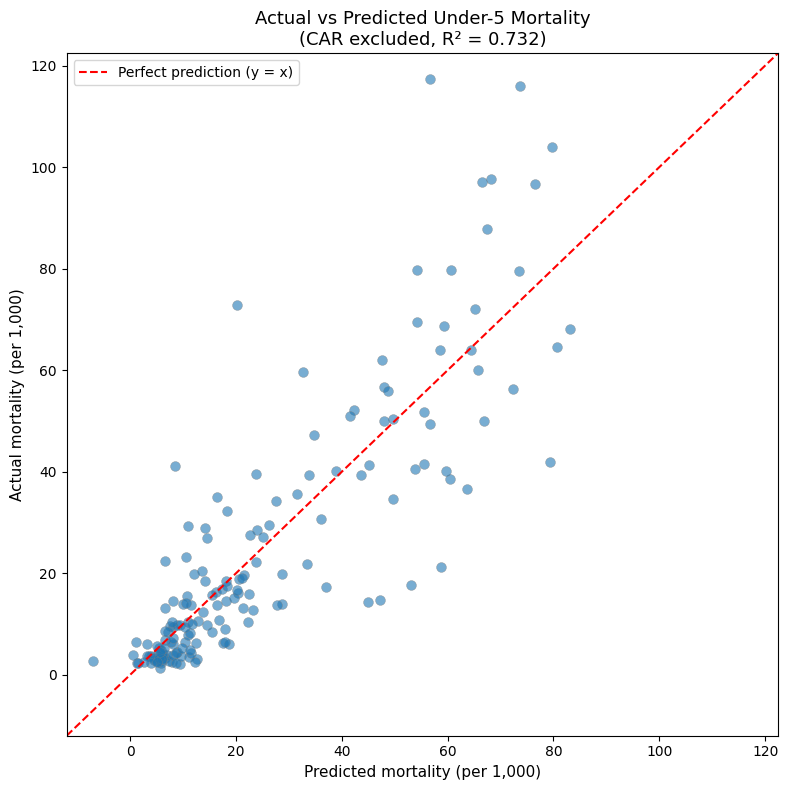

In [13]:
# Assumes df_no_car and model (the CAR-excluded OLS model) already exist
# from Day 5's residual analysis script.
df_no_car['predicted_mortality'] = model.fittedvalues

fig, ax = plt.subplots(figsize=(8, 8))

actual = df_no_car['per_1000']
predicted = df_no_car['predicted_mortality']

ax.scatter(predicted, actual, alpha=0.6, s=50, edgecolors='grey', linewidths=0.4)

# Perfect-prediction reference line (y = x)
lims = [min(actual.min(), predicted.min()) - 5, max(actual.max(), predicted.max()) + 5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y = x)')

ax.set_xlabel('Predicted mortality (per 1,000)', fontsize=11)
ax.set_ylabel('Actual mortality (per 1,000)', fontsize=11)
ax.set_title('Actual vs Predicted Under-5 Mortality\n(CAR excluded, R² = 0.732)', fontsize=13)
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 13'}/week2_day6_actual_vs_predicted.png', dpi=150)
plt.show()

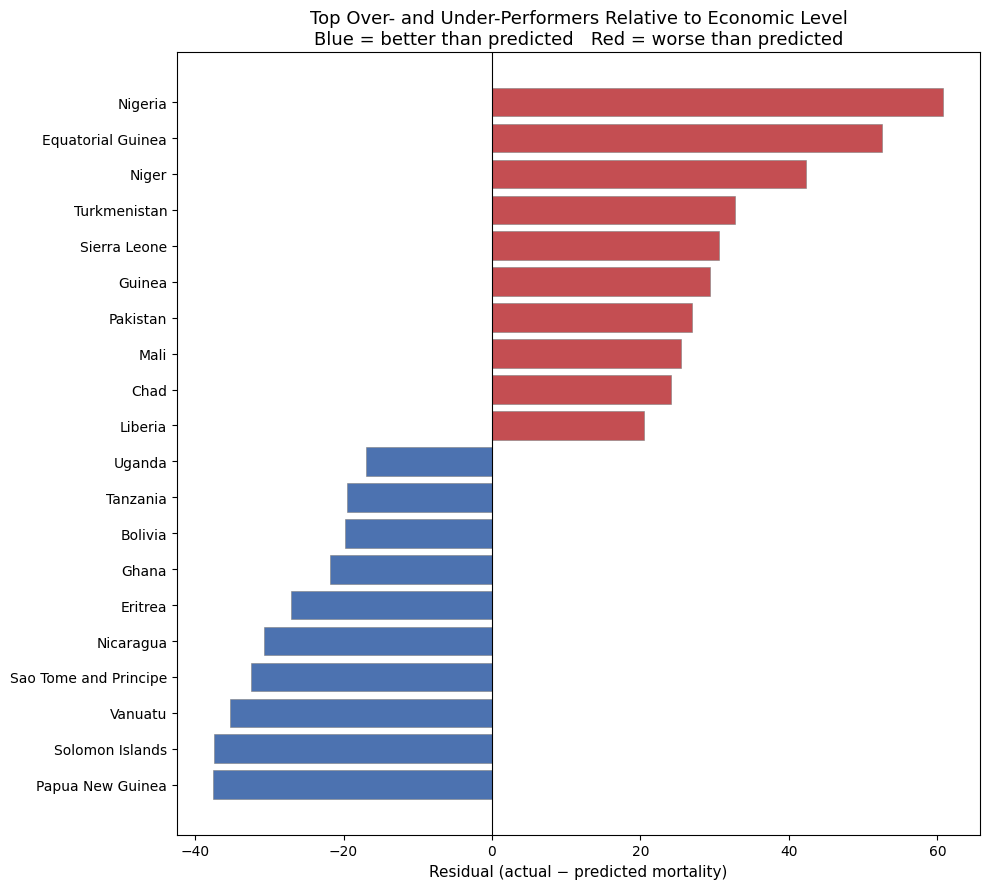

In [15]:
# Assumes df_no_car (with 'residual' column) exists from Day 5's script.
df_no_car['residual'] = df_no_car[target] - df_no_car['predicted_mortality']

top_over = df_no_car.sort_values('residual').head(10)
top_under = df_no_car.sort_values('residual', ascending=False).head(10)

# Combine, over-performers first (most negative) up to under-performers (most positive)
combined = pd.concat([top_over, top_under]).sort_values('residual')

fig, ax = plt.subplots(figsize=(10, 9))

colors = ['#4C72B0' if r < 0 else '#C44E52' for r in combined['residual']]

ax.barh(combined['entity'], combined['residual'], color=colors, edgecolor='grey', linewidth=0.4)
ax.axvline(x=0, color='black', linewidth=0.8)

ax.set_xlabel('Residual (actual − predicted mortality)', fontsize=11)
ax.set_title(
    'Top Over- and Under-Performers Relative to Economic Level\n'
    'Blue = better than predicted   Red = worse than predicted',
    fontsize=13
)

plt.tight_layout()
plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 13'}/week2_day6_ranked_performers.png', dpi=150)
plt.show()